In [1]:
import sys

import pandas as pd
from pathlib import Path
from dataclasses import asdict
from pprint import pprint

sys.path.append(str(Path.cwd().parent))

from src.data_loader import ParquetDataLoader

from src.features.fdr_weights import FDRWeightComputer
from src.features.peak_features import PeakFeatureComputer
from src.features.spectrum_features import SpectrumFeatureComputer
from src.processing.spectrum_processor import SpectrumProcessor
from src.config import load_config, load_training_config
from src.splitting.splitter import GroupedSpectrumSplitter, SplitConfig
#from src.model.mlp import MLPConfig, MLPPeakClassifier
from src.training.train_mlp import train_mlp

from src.model.mlp import MLPPeakClassifier



In [4]:
DUPLIC_PATH = "../../../data/annotations_noloss_all.parquet"
UNIQUE_LOADER = ParquetDataLoader(DUPLIC_PATH)
UNIQUE_DF = UNIQUE_LOADER.load()
print(UNIQUE_LOADER.counts())

{'rows': 244335, 'columns': 10, 'duplicate_rows': 69499}


In [ ]:
UNIQUE_LOADER.preview()

In [6]:
sum(UNIQUE_DF['raw_raptor'] != True)

167261

In [18]:
sum(UNIQUE_DF['fdr'] <= 0.5)

244335

In [7]:
sum(UNIQUE_DF['raw_raptor'] != False)

77074

In [ ]:
print(UNIQUE_DF["PeakListFileName"].dropna().unique())

In [ ]:
print(
      UNIQUE_DF.loc[
          UNIQUE_DF["raw_raptor"].ne(True).fillna(True),
          "PeakListFileName"
      ]
)


In [13]:
import numpy as np
all_masks = np.concatenate(UNIQUE_DF["annotation_mask"].to_numpy())
n_true = np.count_nonzero(all_masks)
n_false = all_masks.size - n_true

print(f"# Target Peaks:  {n_true}")
print(f"# Noise Peaks: {n_false}")
mask = UNIQUE_DF["PeakListFileName"].astype(str).str.startswith(("L1_", "1_HSA_SDA"))
print(f"Rows to remove: {mask.sum()}")

UNIQUE_DF_REMOVED = UNIQUE_DF.loc[mask].copy()
UNIQUE_DF_FILTERED = UNIQUE_DF.loc[~mask].copy()

print(f"Remaining rows: {len(UNIQUE_DF_FILTERED)}")

removed_masks = np.concatenate(UNIQUE_DF_REMOVED["annotation_mask"].to_numpy())
removed_true = np.count_nonzero(removed_masks)
removed_false = removed_masks.size - removed_true

print(f"Removed # Target Peaks: {removed_true}")
print(f"Removed # Noise Peaks:  {removed_false}")

all_masks = np.concatenate(UNIQUE_DF_FILTERED["annotation_mask"].to_numpy())
n_true = np.count_nonzero(all_masks)
n_false = all_masks.size - n_true

print(f"Remaining # Target Peaks: {n_true}")
print(f"Remaining # Noise Peaks:  {n_false}")



# Target Peaks:  16666873
# Noise Peaks: 240226619
Rows to remove: 14996
Remaining rows: 229339
Removed # Target Peaks: 3321467
Removed # Noise Peaks:  61458409
Remaining # Target Peaks: 13345406
Remaining # Noise Peaks:  178768210


       n_target   n_noise
group                    
A       5863762  27352411
Z       1211303   4342568
R        971979   4054253


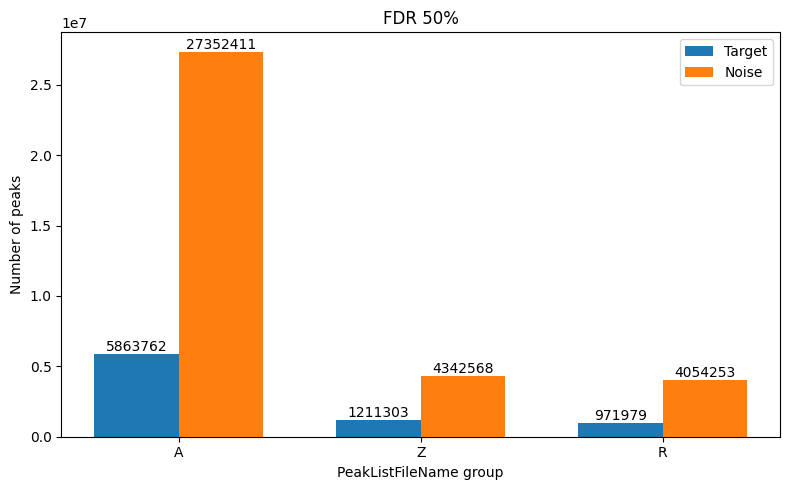

In [19]:
import matplotlib.pyplot as plt

plot_df = UNIQUE_DF_FILTERED.copy()

plot_df["group"] = (
    plot_df["PeakListFileName"]
    .astype(str)
    .str.extract(r"_(A|Z|R)_", expand=False)
)

plot_df = plot_df.dropna(subset=["group"]).copy()

plot_df["n_target"] = plot_df["annotation_mask"].apply(lambda x: int(np.count_nonzero(x)))
plot_df["n_noise"] = plot_df["annotation_mask"].apply(lambda x: int(x.size - np.count_nonzero(x)))

summary_df = (
    plot_df.groupby("group")[["n_target", "n_noise"]]
    .sum()
    .reindex(["A", "Z", "R"])
    .fillna(0)
    .astype(int)
)

print(summary_df)
all_masks = np.concatenate(UNIQUE_DF_FILTERED["annotation_mask"].to_numpy())
n_true = np.count_nonzero(all_masks)
n_false = all_masks.size - n_true
#assert(sum(summary_df['n_target']) == n_true)
#assert(sum(summary_df['n_noise']) == n_false)
#summary_df.loc["Removed"] = [removed_true, removed_false]


x = np.arange(len(summary_df.index))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars_target = ax.bar(x - width / 2, summary_df["n_target"], width, label="Target")
bars_noise = ax.bar(x + width / 2, summary_df["n_noise"], width, label="Noise")
ax.set_title("FDR 50%")
ax.set_xticks(x)
ax.set_xticklabels(summary_df.index)
ax.set_xlabel("PeakListFileName group")
ax.set_ylabel("Number of peaks")
ax.legend()

for bars in [bars_target, bars_noise]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()

In [30]:
# Filter by 5% FDR
FDR_5PCT_DF = UNIQUE_DF[UNIQUE_DF["fdr"] <= 0.05].copy()
import numpy as np
all_masks = np.concatenate(FDR_5PCT_DF["annotation_mask"].to_numpy())
n_true = np.count_nonzero(all_masks)
n_false = all_masks.size - n_true

print(f"# Target Peaks:  {n_true}")
print(f"# Noise Peaks: {n_false}")
mask = FDR_5PCT_DF["PeakListFileName"].astype(str).str.startswith(("L1_", "1_HSA_SDA"))
print(f"Rows to remove: {mask.sum()}")

UNIQUE_DF_REMOVED = FDR_5PCT_DF.loc[mask].copy()
UNIQUE_DF_FILTERED = FDR_5PCT_DF.loc[~mask].copy()

print(f"Remaining rows: {len(UNIQUE_DF_FILTERED)}")

removed_masks = np.concatenate(UNIQUE_DF_REMOVED["annotation_mask"].to_numpy())
removed_true = np.count_nonzero(removed_masks)
removed_false = removed_masks.size - removed_true

print(f"Removed # Target Peaks: {removed_true}")
print(f"Removed # Noise Peaks:  {removed_false}")

all_masks = np.concatenate(UNIQUE_DF_FILTERED["annotation_mask"].to_numpy())
n_true = np.count_nonzero(all_masks)
n_false = all_masks.size - n_true

print(f"Remaining # Target Peaks: {n_true}")
print(f"Remaining # Noise Peaks:  {n_false}")


# Target Peaks:  6149119
# Noise Peaks: 72710838
Rows to remove: 7869
Remaining rows: 60127
Removed # Target Peaks: 1763288
Removed # Noise Peaks:  30480265
Remaining # Target Peaks: 4385831
Remaining # Noise Peaks:  42230573


In [32]:
sum(UNIQUE_DF_FILTERED['fdr'] > 0.05)

0

       n_target  n_noise
group                   
A       1663482  4602857
Z        649040  1663484
R        755930  2421674


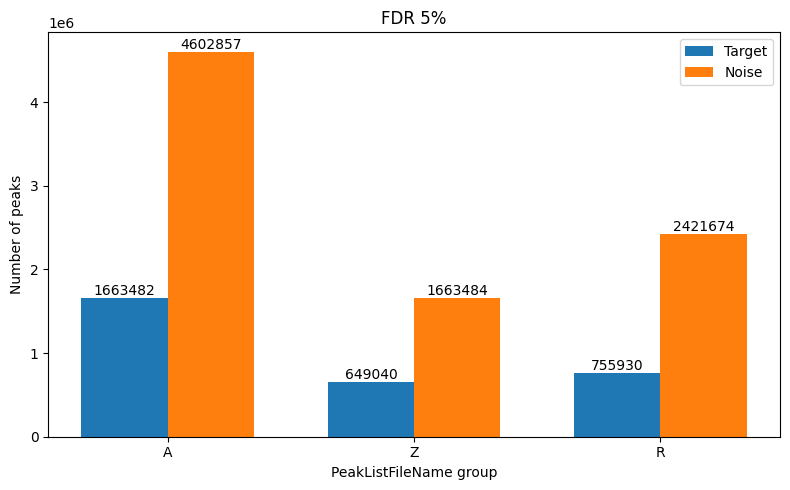

In [33]:


import matplotlib.pyplot as plt

plot_df = UNIQUE_DF_FILTERED.copy()

plot_df["group"] = (
    plot_df["PeakListFileName"]
    .astype(str)
    .str.extract(r"_(A|Z|R)_", expand=False)
)

plot_df = plot_df.dropna(subset=["group"]).copy()

plot_df["n_target"] = plot_df["annotation_mask"].apply(lambda x: int(np.count_nonzero(x)))
plot_df["n_noise"] = plot_df["annotation_mask"].apply(lambda x: int(x.size - np.count_nonzero(x)))

summary_df = (
    plot_df.groupby("group")[["n_target", "n_noise"]]
    .sum()
    .reindex(["A", "Z", "R"])
    .fillna(0)
    .astype(int)
)

print(summary_df)
all_masks = np.concatenate(UNIQUE_DF_FILTERED["annotation_mask"].to_numpy())
n_true = np.count_nonzero(all_masks)
n_false = all_masks.size - n_true
#assert(sum(summary_df['n_target']) == n_true)
#assert(sum(summary_df['n_noise']) == n_false)
#summary_df.loc["Removed"] = [removed_true, removed_false]


x = np.arange(len(summary_df.index))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars_target = ax.bar(x - width / 2, summary_df["n_target"], width, label="Target")
bars_noise = ax.bar(x + width / 2, summary_df["n_noise"], width, label="Noise")
ax.set_title("FDR 5%")
ax.set_xticks(x)
ax.set_xticklabels(summary_df.index)
ax.set_xlabel("PeakListFileName group")
ax.set_ylabel("Number of peaks")
ax.legend()

for bars in [bars_target, bars_noise]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom"
        )

plt.tight_layout()
plt.show()


In [35]:
sum(UNIQUE_DF_FILTERED['raw_raptor'] != True)

44511

In [36]:
sum(UNIQUE_DF_FILTERED['raw_raptor'] == True)

15616

In [40]:
UNIQUE_DF_FILTERED["recali"] = ~UNIQUE_DF_FILTERED["raw_raptor"]

In [ ]:
UNIQUE_DF_FILTERED

(60127, 11)
['SearchID', 'PeakListFileName', 'scan', 'mz_arr', 'int_arr', 'Charge', 'exp m/z', 'annotation_mask', 'fdr', 'raw_raptor', 'recali']


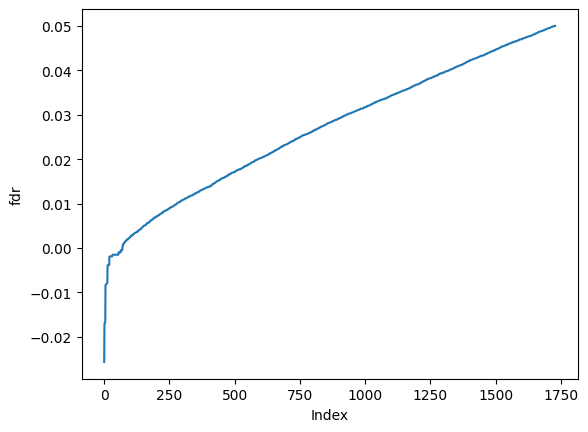

In [42]:
print(UNIQUE_DF_FILTERED.shape)
print(UNIQUE_DF_FILTERED.columns.tolist())
VALS = sorted(UNIQUE_DF_FILTERED["fdr"].dropna().unique())

plt.plot(VALS)
plt.xlabel("Index")
plt.ylabel("fdr")
plt.show()

In [ ]:
## Ready to split dataset: 
UNIQUE_DF_FILTERED.to_parquet("labeled_new_29962926_5pct.parquet", index=False)